In [34]:
import sys
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report
)

sys.path.append(os.path.abspath("../src"))

from models import ResNet18

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    create_binary_target,
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

# Data Preprocessing

## Data Exploration

In [35]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")

# Prepare the full dataframe with all necessary columns
# - Loads dataframe from csv
# - Creates new column "image_path" for image root directory + image filename
# - Creates binary target variable "target" where 0 = "No Finding" and 1 = any other finding
# - Creates column to split the data into train/val/test based on the "Patient ID" column
df = prepare_full_dataframe(metadata_file, dataset_path)

print(df.head())
print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays


Train Epoch 1:   1%|          | 26/2467 [00:45<1:11:15,  1.75s/it, avg_acc=0.5529, avg_loss=0.8574, batch_loss=0.7473]


        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  \
0                        0.143  0.143          NaN

In [36]:
# Analyze the distribution of findings
df["Finding Labels"].value_counts().head()

Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [37]:
# Analyze the distribution of the binary target variable
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [38]:
# Analyze target proportions
_, target_proportions = create_binary_target(df)
print("Target proportions:", target_proportions)

Target proportions: target
0    0.538361
1    0.461639
Name: proportion, dtype: float64


In [39]:
missing = df["image_path"].isna().sum()
print(f"Missing images:", missing)

Missing images: 0


## Create Data Loaders

In [40]:
# Prepare the data loaders
train_loader, val_loader, test_loader = prepare_data(df)

## Sanity Check

In [41]:
# Check the shapes of the batches on one batch
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Unique labels:", labels.unique())

Image batch shape: torch.Size([32, 1, 224, 224])
Label batch shape: torch.Size([32])
Unique labels: tensor([0, 1])


# ResNet18

## Initialize Model

In [42]:
device = get_device()

model = ResNet18(num_classes=2, in_channels=1, pretrained=True).to(device)
# Uses pretrained weights

criterion, optimizer = setup_training(model)

Using MPS (GPU)


/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training the Model

In [33]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "resnet18_binary_target", 10)

KeyboardInterrupt: 

## Analyze Training History

In [ ]:
plot_training_history(history)

NameError: name 'history' is not defined

# Best Model Testing

In [ ]:
save_path = get_model_path("resnet18_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = ResNet18(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/resnet18_binary_target.pt


Test Results
  Loss: 0.6166
  Accuracy: 0.6758
  Precision: 0.6294
  Recall: 0.7256
  F1 Score: 0.6741


## Evaluating Test Results

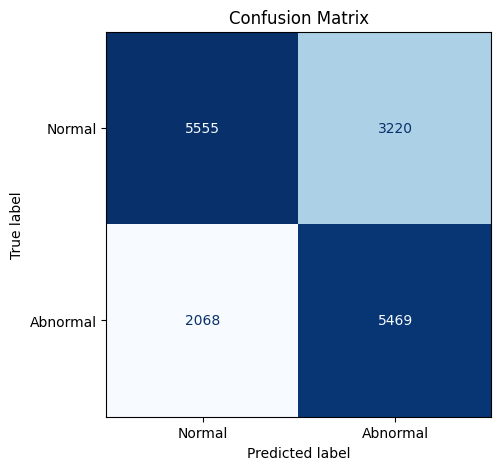

In [ ]:
plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

# Making Prediction

In [ ]:
image_path = sample_image_path(df, split="test")
_, eval_transforms = get_transforms()  # Get the evaluation transforms (no augmentation)

result = predict_single_image(image_path, best_model, device, eval_transforms)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"])
print("Probabilities:", result["probabilities"])


Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_001/images/00000096_008.png
Predicted class: abnormal
Probabilities: {'normal': 0.18292683362960815, 'abnormal': 0.8170732259750366}
